# **Predictive Maintenance - Interim Report**

## Business Problem

**Predictive Maintenance for Engine Failure Detection**

Unexpected engine failures can result in:
- expensive repairs
- operational downtime
- safety risks
- reduced equipment lifespan

Predictive maintenance enables organizations to proactively identify engine issues before catastrophic failures occur.

## Objective

The objective of this project is to build a machine learning model capable of predicting engine maintenance requirements using engine sensor data such as:

- RPM
- Lubricating oil pressure
- Fuel pressure
- Coolant pressure
- Oil temperature
- Coolant temperature

The final solution aims to:

- reduce unplanned downtime
- optimize maintenance schedules
- improve engine reliability
- support data-driven operational decisions

## Import Libraries

In [1]:
# Install mlflow and huggingface
!pip install -q mlflow datasets huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.5/901.5 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

In [2]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Model Saving
import joblib

# mlflow
import mlflow
import mlflow.sklearn

# Hugging Face
from huggingface_hub import login
from datasets import Dataset
from datasets import load_dataset
from huggingface_hub import create_repo
from huggingface_hub import HfApi

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Data Overview

In [3]:
df = pd.read_csv('/content/engine_data.csv')

In [4]:
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [5]:
df.shape

(19535, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


In [7]:
df.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


**Statistical Insights**

- Engine RPM values demonstrate a broad operational range, indicating varying engine workloads and operating conditions.
- Lubricating oil pressure and fuel pressure exhibit moderate variability, suggesting diverse engine performance states across observations.
- Coolant and lubrication temperatures show noticeable spread, which may indicate fluctuations in thermal operating conditions.
- The absence of extremely abnormal statistical ranges suggests the dataset is reasonably well-structured for predictive modeling.
- Standard deviation values across sensor features indicate sufficient variability for machine learning algorithms to learn meaningful patterns.

In [8]:
df.isnull().sum()

,0
Engine rpm,0
Lub oil pressure,0
Fuel pressure,0
Coolant pressure,0
lub oil temp,0
Coolant temp,0
Engine Condition,0


In [9]:
df.duplicated().sum()

np.int64(0)

## Data Registration

Dataset Repository

https://huggingface.co/datasets/ShauryaRawatRwt/Predictive_Maintenance

In [10]:
login()

In [12]:
dataset = Dataset.from_pandas(df)

dataset.push_to_hub("ShauryaRawatRwt/Predictive_Maintenance")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/20 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  92%|#########2|  931kB / 1.01MB            

README.md:   0%|          | 0.00/543 [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/ShauryaRawatRwt/Predictive_Maintenance/commit/1960504111953bdb88a66b4b0315a7dd9bcfa628', commit_message='Upload dataset', commit_description='', oid='1960504111953bdb88a66b4b0315a7dd9bcfa628', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/ShauryaRawatRwt/Predictive_Maintenance', endpoint='https://huggingface.co', repo_type='dataset', repo_id='ShauryaRawatRwt/Predictive_Maintenance'), pr_revision=None, pr_num=None)

In [13]:
dataset = load_dataset("ShauryaRawatRwt/Predictive_Maintenance")

df = dataset['train'].to_pandas()

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.01M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19535 [00:00<?, ? examples/s]

## EDA - Exploratory Data Analysis

#### Target Variable Distribution
Analyzing the balance between healthy and faulty engine conditions is important to assess dataset balance and model reliability.

In [14]:
df['Engine Condition'].value_counts()

,count
Engine Condition,
1,12317
0,7218


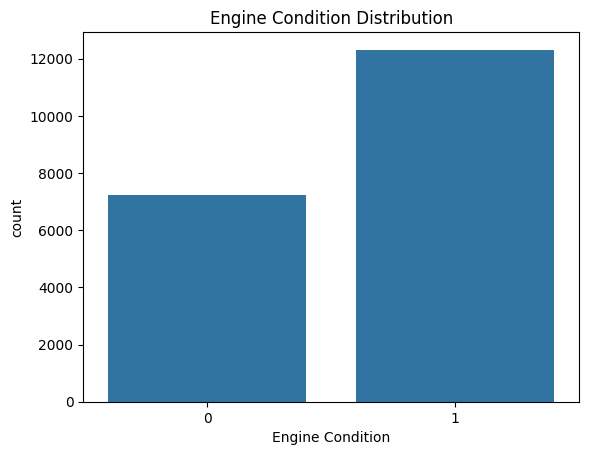

In [15]:
sns.countplot(x='Engine Condition', data=df)
plt.title('Engine Condition Distribution')
plt.show()

**Observation:**

The target classes appear relatively balanced, which is beneficial for classification modeling and reduces the risk of model bias toward a single class.

#### **Univariate Analysis**

Univariate analysis helps understand the distribution, spread, and outliers present in individual engine sensor variables.

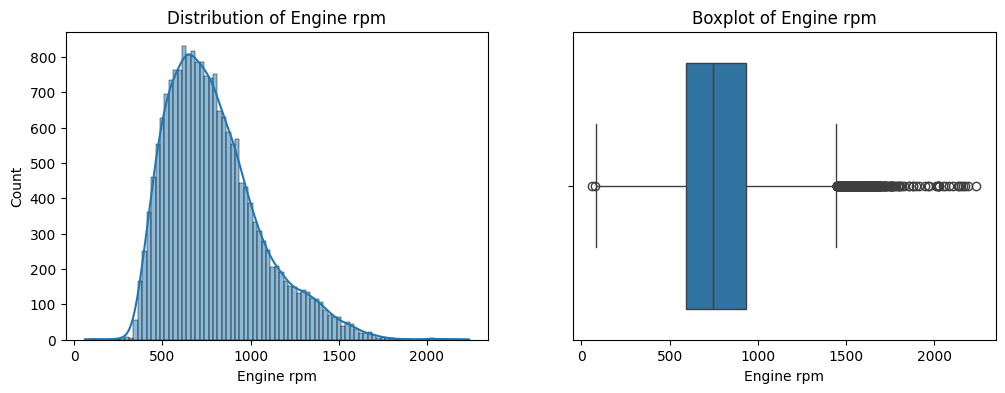

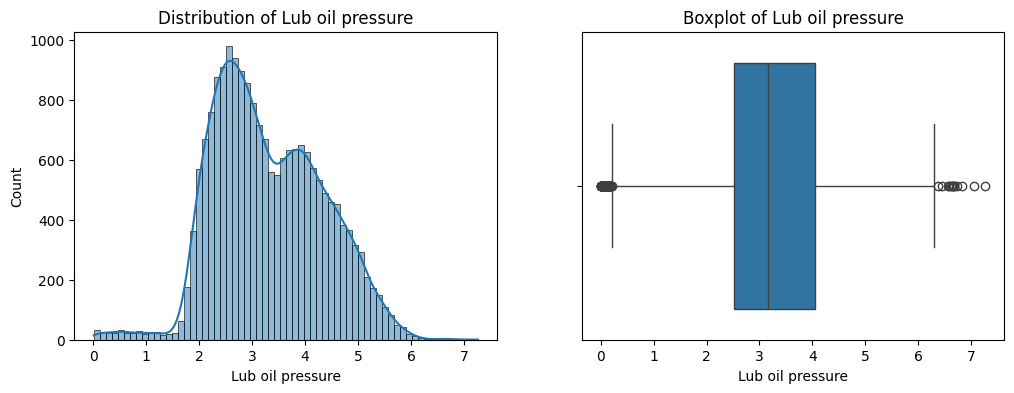

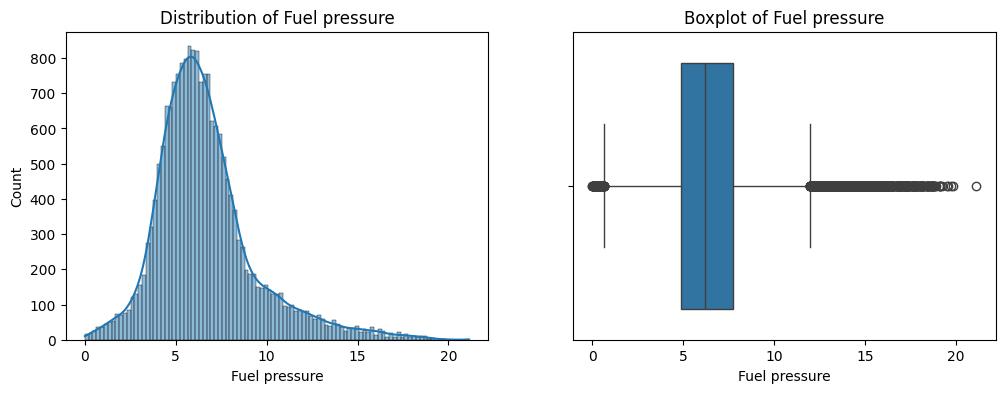

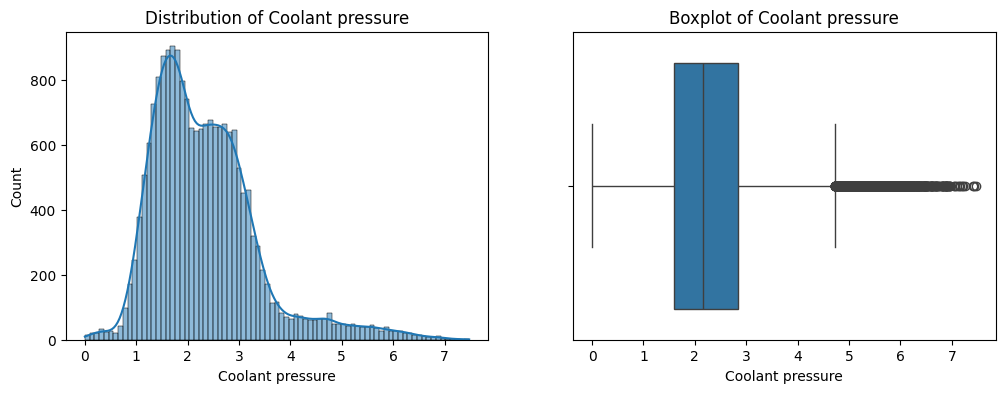

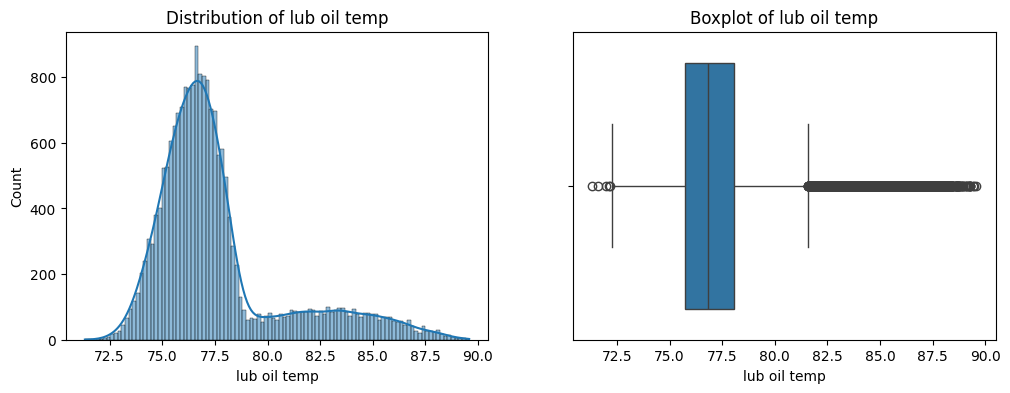

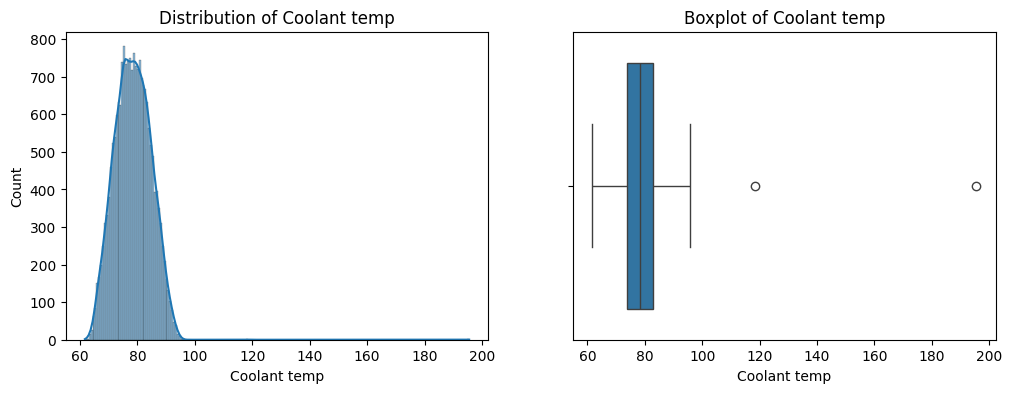

In [16]:
columns = df.columns[:-1]

for col in columns:
    fig, axes = plt.subplots(1,2, figsize=(12,4))

    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    plt.show()

**Key Observations**
- Engine RPM values are distributed across varying operational ranges.
- Certain sensor variables exhibit outliers, potentially indicating abnormal engine behavior.
- Lubricating oil and coolant temperatures show noticeable variation across records.
- No severe anomalies were observed that require immediate removal.

#### **Bivariate Analysis**

Bivariate analysis evaluates the relationship between sensor readings and engine condition.

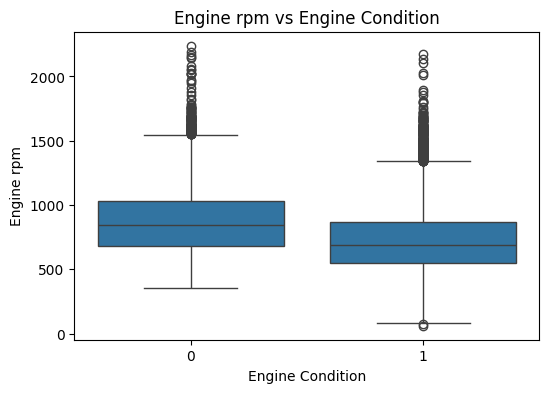

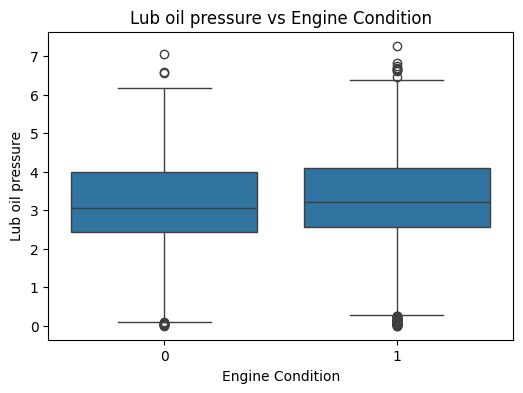

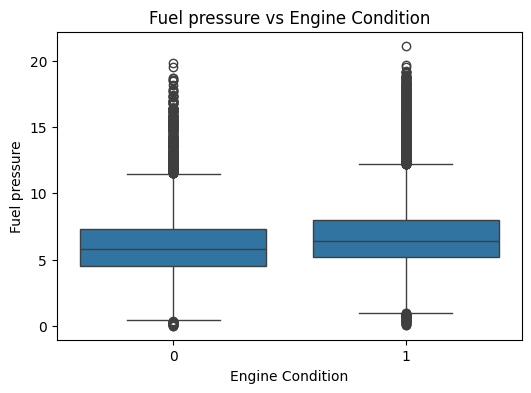

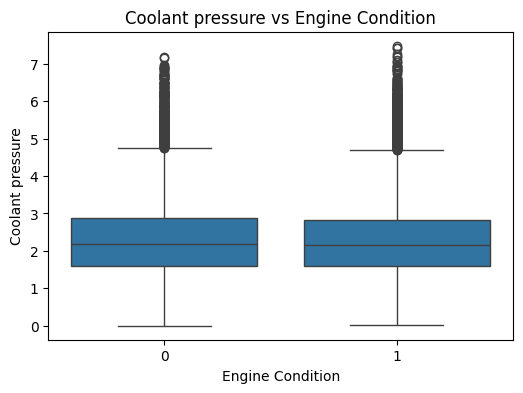

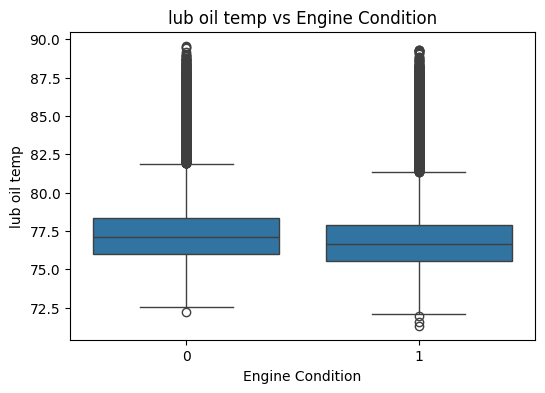

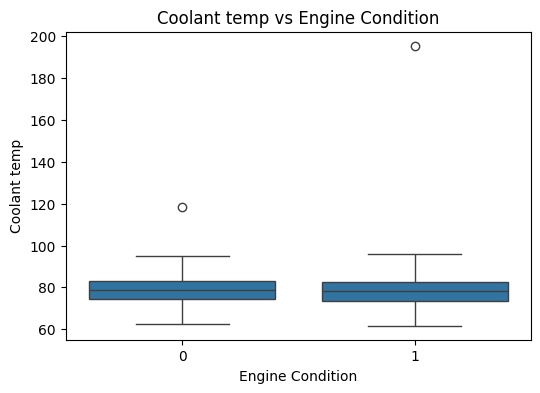

In [17]:
features = df.columns[:-1]

for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Engine Condition', y=col, data=df)
    plt.title(f'{col} vs Engine Condition')
    plt.show()

**Key Observations**

- Faulty engines tend to exhibit abnormal coolant and lubrication characteristics.
- Sensor readings show distinguishable patterns between healthy and maintenance-required engines.
- Temperature and pressure variables appear influential in predicting engine condition.

#### **Multivariate Analysis**

Multivariate analysis helps identify relationships among multiple engine parameters simultaneously.

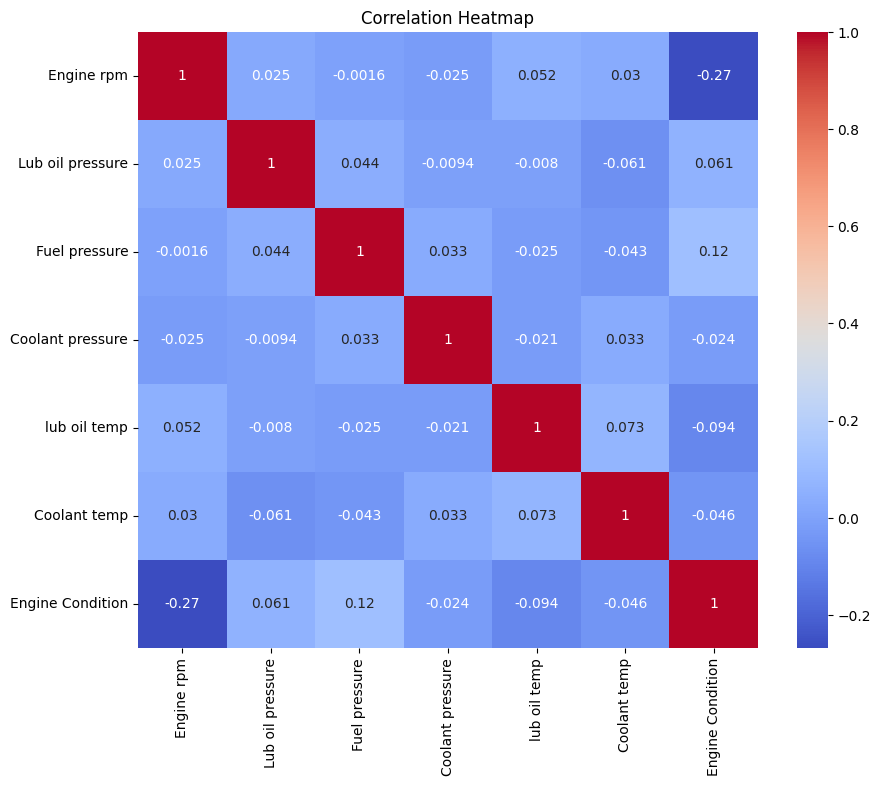

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Insights from Multivariate Analysis**

- Several engine sensor variables exhibit moderate correlation with engine condition, indicating their importance in predictive maintenance modeling.
- Lubricating oil temperature and coolant temperature show positive correlation, suggesting interconnected thermal behavior within engine operations.
- Pressure-related variables demonstrate varying levels of association, highlighting their contribution toward identifying abnormal engine states.
- No extreme multicollinearity was observed among the features, indicating that the dataset is suitable for machine learning model development without significant redundancy.
- The correlation patterns suggest that combining temperature, pressure, and RPM-related features can improve predictive maintenance classification performance.
- The multivariate relationships confirm that engine failures are influenced by multiple operational parameters rather than a single sensor reading.

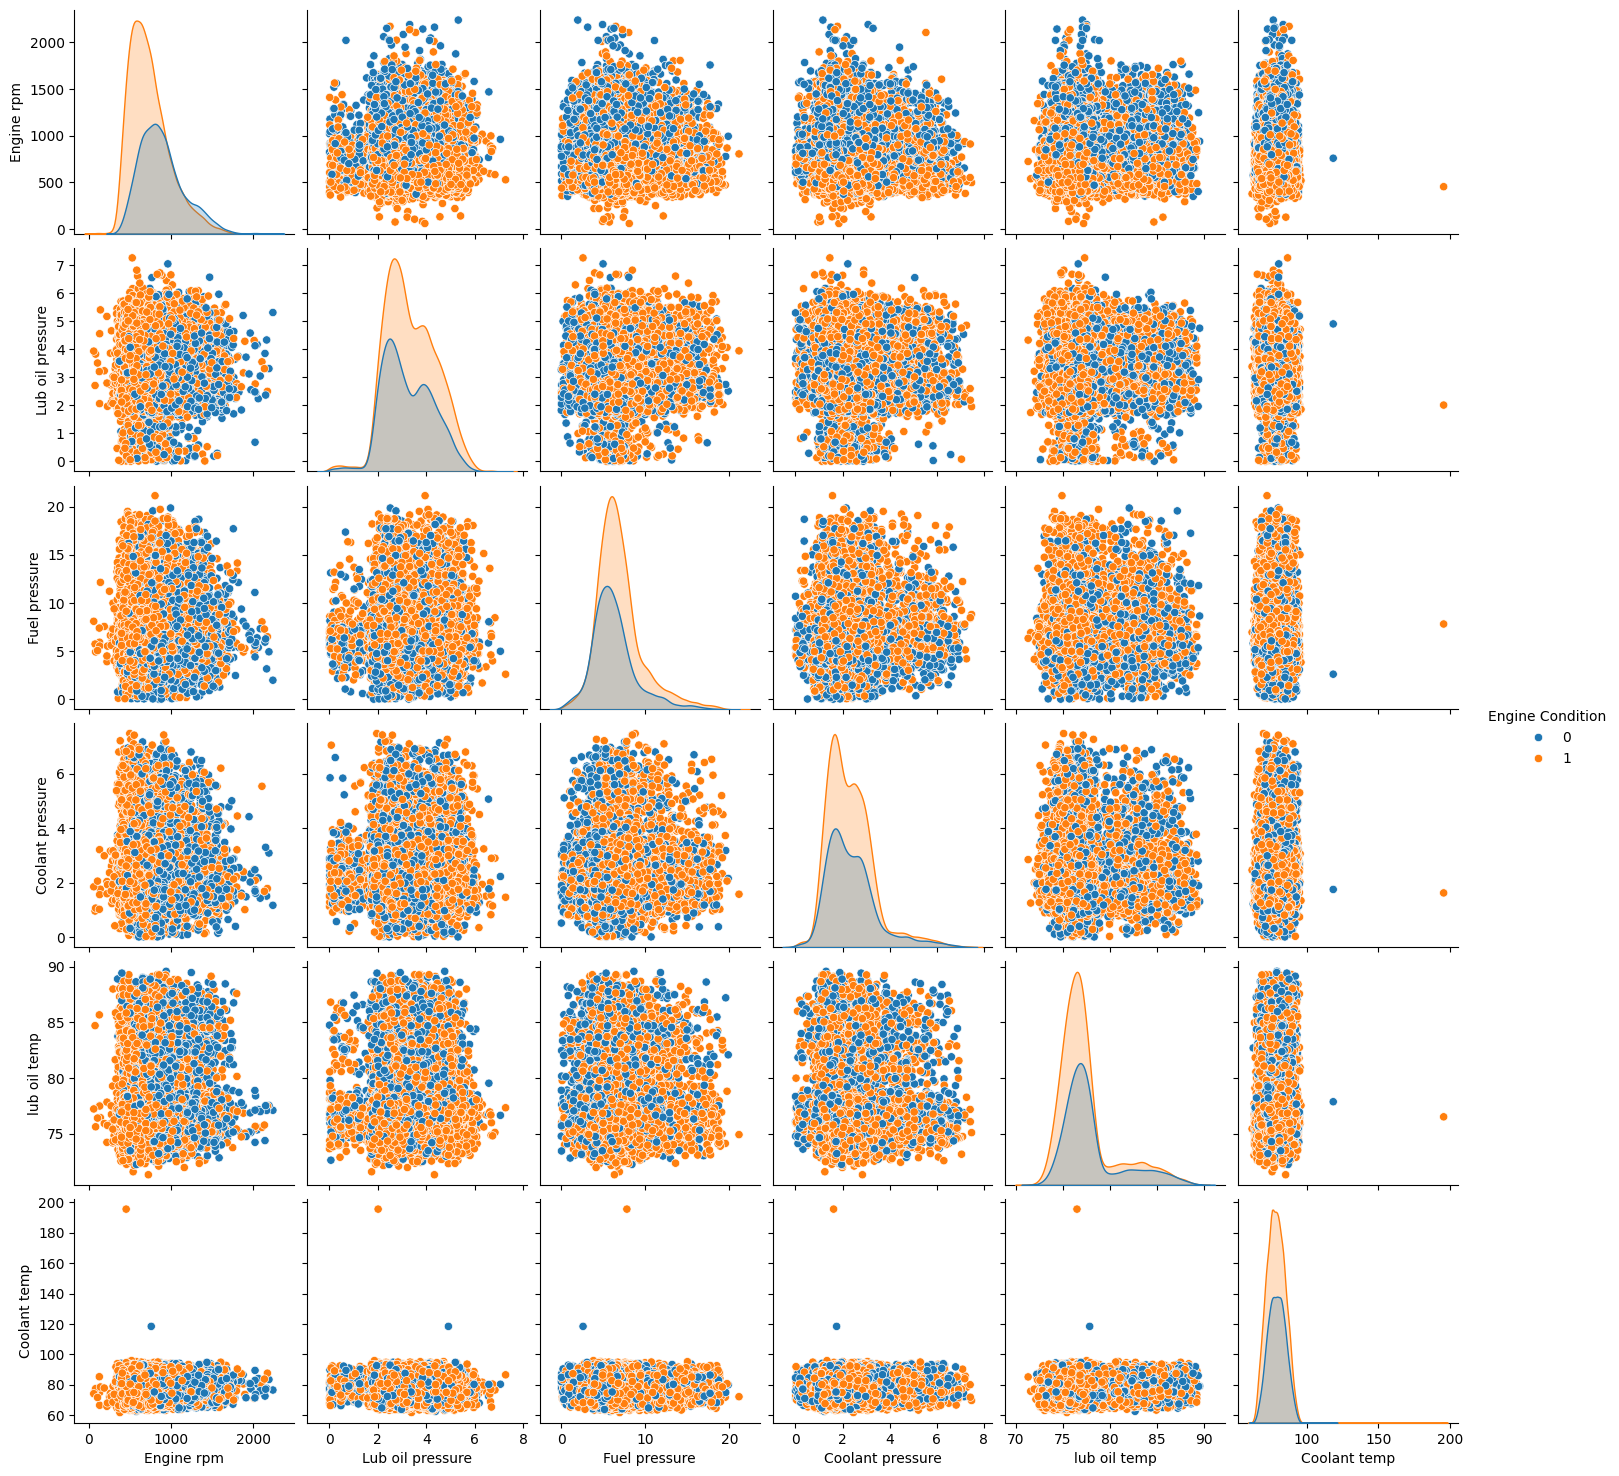

In [19]:
sns.pairplot(df, hue='Engine Condition')
plt.show()

**Key Insights**
- Several sensor variables demonstrate moderate correlation with engine condition.
- Temperature-related variables show interdependency.
- The dataset contains sufficient feature variation for machine learning classification.

## Data Preparation

This section prepares the dataset for machine learning model development.

The dataset was checked for:
- missing values
- duplicate records
- datatype consistency

No major data quality issues were identified.

#### Feature-target split

In [20]:
X = df.drop('Engine Condition', axis=1)
y = df['Engine Condition']

#### Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

In [23]:
train_df = X_train.copy()
train_df['Engine Condition'] = y_train

test_df = X_test.copy()
test_df['Engine Condition'] = y_test

train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

In [24]:
api = HfApi()

api.upload_file(
    path_or_fileobj="train.csv",
    path_in_repo="data/train.csv",
    repo_id="ShauryaRawatRwt/Predictive_Maintenance",
    repo_type="dataset"
)

api.upload_file(
    path_or_fileobj="test.csv",
    path_in_repo="data/test.csv",
    repo_id="ShauryaRawatRwt/Predictive_Maintenance",
    repo_type="dataset"
)

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/ShauryaRawatRwt/Predictive_Maintenance/commit/1960504111953bdb88a66b4b0315a7dd9bcfa628', commit_message='Upload data/test.csv with huggingface_hub', commit_description='', oid='1960504111953bdb88a66b4b0315a7dd9bcfa628', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/ShauryaRawatRwt/Predictive_Maintenance', endpoint='https://huggingface.co', repo_type='dataset', repo_id='ShauryaRawatRwt/Predictive_Maintenance'), pr_revision=None, pr_num=None)

## Model Building

Multiple classification models were trained and compared to identify the best-performing predictive maintenance solution.
Models used for evaluation:
1. Decision Tree
2. Random Forest
3. Gradient Boosting

#### Decision Tree

In [25]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

#### Random Forest

In [26]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

#### Gradient Boosting

In [27]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

## Model Evaluation

In [28]:
def evaluate_model(y_test, pred, model_name):

    print(f"Model: {model_name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("F1 Score:", f1_score(y_test, pred))
    print("ROC-AUC:", roc_auc_score(y_test, pred))

    print("\nClassification Report\n")
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

#### Evaluate all models

Model: Decision Tree
Accuracy: 0.5930381366777578
Precision: 0.6749498997995992
Recall: 0.6837190418189201
F1 Score: 0.6793061718434853
ROC-AUC: 0.5610423463942246

Classification Report

              precision    recall  f1-score   support

           0       0.45      0.44      0.44      1444
           1       0.67      0.68      0.68      2463

    accuracy                           0.59      3907
   macro avg       0.56      0.56      0.56      3907
weighted avg       0.59      0.59      0.59      3907



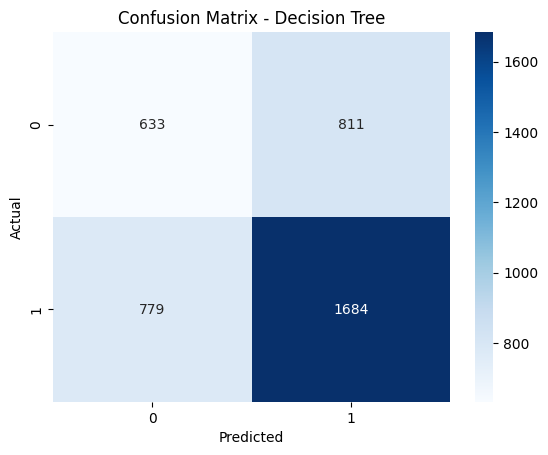

Model: Random Forest
Accuracy: 0.6452521115945739
Precision: 0.6887486855941115
Recall: 0.7978075517661388
F1 Score: 0.7392776523702032
ROC-AUC: 0.5914245515063381

Classification Report

              precision    recall  f1-score   support

           0       0.53      0.39      0.45      1444
           1       0.69      0.80      0.74      2463

    accuracy                           0.65      3907
   macro avg       0.61      0.59      0.59      3907
weighted avg       0.63      0.65      0.63      3907



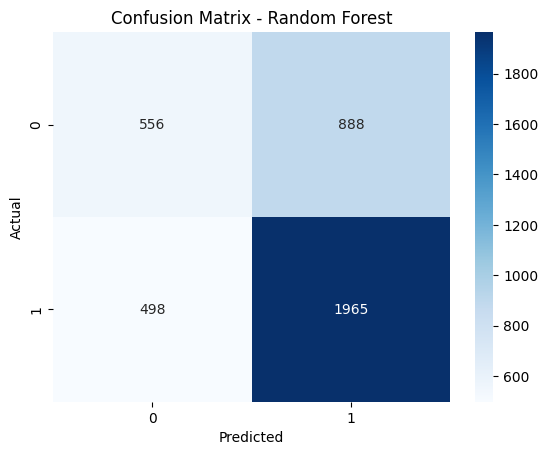

Model: Gradient Boosting
Accuracy: 0.6647043767596621
Precision: 0.691974691974692
Recall: 0.8436865611043443
F1 Score: 0.7603366264178558
ROC-AUC: 0.6015524218264103

Classification Report

              precision    recall  f1-score   support

           0       0.57      0.36      0.44      1444
           1       0.69      0.84      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.60      0.60      3907
weighted avg       0.65      0.66      0.64      3907



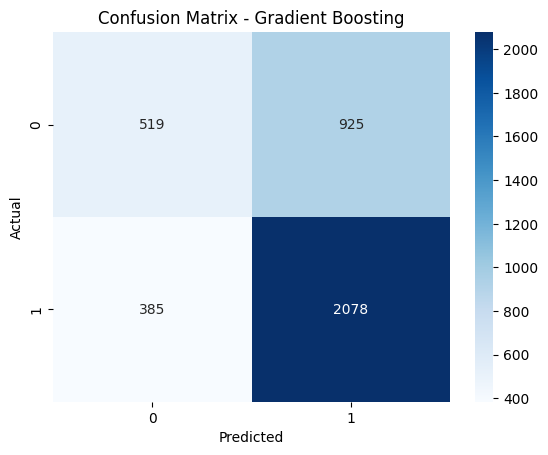

In [29]:
evaluate_model(y_test, dt_pred, "Decision Tree")
evaluate_model(y_test, rf_pred, "Random Forest")
evaluate_model(y_test, gb_pred, "Gradient Boosting")

## Model Comparison Summary

In [30]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    'Precision': [
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    'Recall': [
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    'F1 Score': [
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, dt_pred),
        roc_auc_score(y_test, rf_pred),
        roc_auc_score(y_test, gb_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.593038,0.674950,0.683719,0.679306,0.561042
1,Random Forest,0.645252,0.688749,0.797808,0.739278,0.591425
2,Gradient Boosting,0.664704,0.691975,0.843687,0.760337,0.601552


Ensemble-based models such as Random Forest and Gradient Boosting demonstrated superior predictive capability compared to standalone Decision Tree classifiers.

**Gradient Boosting was selected as the final model due to its superior balance between accuracy, recall, and overall classification performance.**

## Hyperparameter Tuning - Gradient Boosting

Gradient Boosting hyperparameters were tuned using GridSearchCV to further optimize predictive maintenance classification performance.

In [31]:
mlflow.set_experiment("Predictive_Maintenance")

2026/05/26 15:56:42 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/26 15:56:42 INFO mlflow.store.db.utils: Updating database tables
2026/05/26 15:56:44 INFO mlflow.tracking.fluent: Experiment with name 'Predictive_Maintenance' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1779811004764, experiment_id='1', last_update_time=1779811004764, lifecycle_stage='active', name='Predictive_Maintenance', tags={}, trace_location=None, workspace='default'>

In [32]:
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

gb_grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [33]:
# Best Parameters
gb_grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

In [34]:
# Best model
best_gb = gb_grid_search.best_estimator_

gb_best_pred = best_gb.predict(X_test)

In [35]:
print("Best Model:", best_gb)

Best Model: GradientBoostingClassifier(learning_rate=0.05, random_state=42)


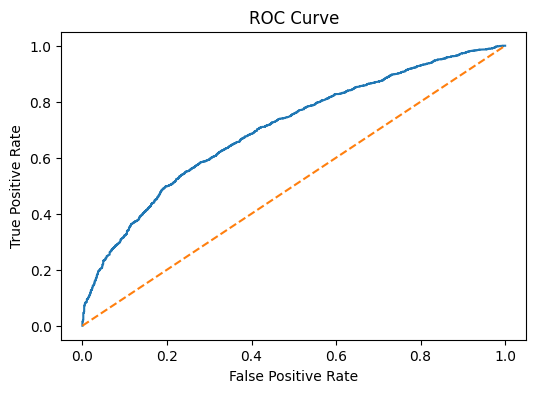

In [36]:
y_prob = best_gb.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.show()

## Experiment Tracking
MLflow was used to track hyperparameters, evaluation metrics, and trained model artifacts to ensure reproducibility and effective experiment management.

In [37]:
with mlflow.start_run():

    mlflow.log_params(gb_grid_search.best_params_)

    mlflow.log_metric(
        "accuracy",
        accuracy_score(y_test, gb_best_pred)
    )

    mlflow.log_metric(
        "f1_score",
        f1_score(y_test, gb_best_pred)
    )

    mlflow.sklearn.log_model(
        best_gb,
        "gradientboosting_model"
    )

2026/05/26 15:59:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 15:59:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## Tuned Model Evaluation

Model: Tuned Gradient Boosting
Accuracy: 0.6670079344765805
Precision: 0.6911184210526315
Recall: 0.853024766544864
F1 Score: 0.7635834999091404
ROC-AUC: 0.6013738791173073

Classification Report

              precision    recall  f1-score   support

           0       0.58      0.35      0.44      1444
           1       0.69      0.85      0.76      2463

    accuracy                           0.67      3907
   macro avg       0.64      0.60      0.60      3907
weighted avg       0.65      0.67      0.64      3907



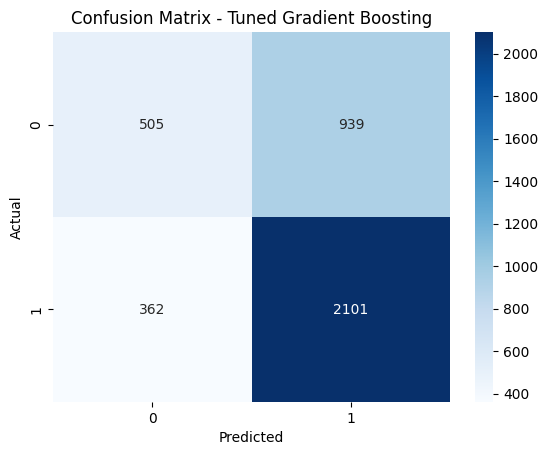

In [38]:
# Evaluate Best Model
evaluate_model(y_test, gb_best_pred, "Tuned Gradient Boosting")

In [39]:
results.loc[len(results)] = [
    'Tuned Gradient Boosting Model',
    accuracy_score(y_test, gb_best_pred),
    precision_score(y_test, gb_best_pred),
    recall_score(y_test, gb_best_pred),
    f1_score(y_test, gb_best_pred),
    roc_auc_score(y_test, gb_best_pred)
]

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.593038,0.674950,0.683719,0.679306,0.561042
1,Random Forest,0.645252,0.688749,0.797808,0.739278,0.591425
2,Gradient Boosting,0.664704,0.691975,0.843687,0.760337,0.601552
3,Tuned Gradient Boosting Model,0.667008,0.691118,0.853025,0.763583,0.601374


## Feature Importance

Feature importance analysis helps identify which engine parameters contribute most significantly to predictive maintenance classification.

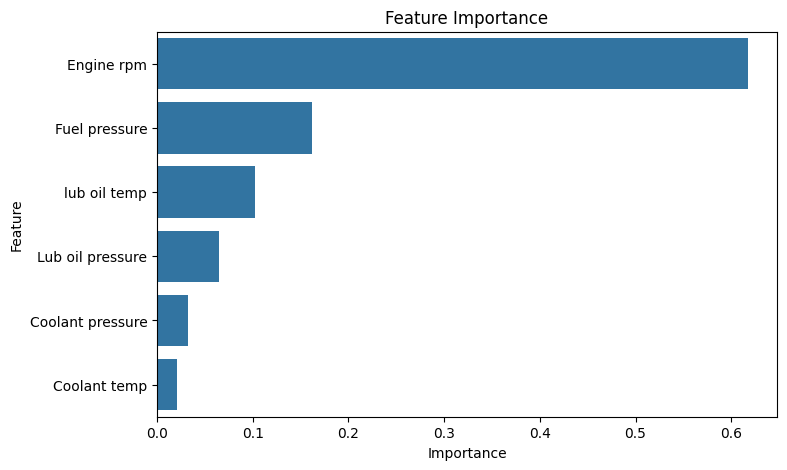

In [40]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance')
plt.show()

Temperature and pressure-related variables emerged as strong predictors of engine condition, highlighting their operational significance in predictive maintenance systems.

In [41]:
# Saving best model
joblib.dump(best_gb, 'best_model.pkl')

['best_model.pkl']

## Model Registration

The best-performing model was registered to the Hugging Face Model Hub for centralized model management and deployment readiness.

Model Repository

https://huggingface.co/ShauryaRawatRwt/Predictive_Maintenance_Model

In [42]:
create_repo(
    repo_id="ShauryaRawatRwt/Predictive_Maintenance_Model",
    repo_type="model",
    exist_ok=True
)

RepoUrl('https://huggingface.co/ShauryaRawatRwt/Predictive_Maintenance_Model', endpoint='https://huggingface.co', repo_type='model', repo_id='ShauryaRawatRwt/Predictive_Maintenance_Model')

In [43]:
api = HfApi()

api.upload_file(
    path_or_fileobj="best_model.pkl",
    path_in_repo="best_model.pkl",
    repo_id="ShauryaRawatRwt/Predictive_Maintenance_Model",
    repo_type="model"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  best_model.pkl              : 100%|##########|  144kB /  144kB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/ShauryaRawatRwt/Predictive_Maintenance_Model/commit/7e7b337043a2a372f8f687c700fe10686af7c2d2', commit_message='Upload best_model.pkl with huggingface_hub', commit_description='', oid='7e7b337043a2a372f8f687c700fe10686af7c2d2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ShauryaRawatRwt/Predictive_Maintenance_Model', endpoint='https://huggingface.co', repo_type='model', repo_id='ShauryaRawatRwt/Predictive_Maintenance_Model'), pr_revision=None, pr_num=None)

## New work

In [44]:
import os

# Main project folder
os.makedirs("predictive-maintenance/data", exist_ok=True)
os.makedirs("predictive-maintenance/models", exist_ok=True)
os.makedirs("predictive-maintenance/app", exist_ok=True)
os.makedirs("predictive-maintenance/.github/workflows", exist_ok=True)
os.makedirs("predictive-maintenance/notebooks", exist_ok=True)
os.makedirs("predictive-maintenance/reports", exist_ok=True)

print("Project folder structure created successfully!")

Project folder structure created successfully!


In [45]:
!find predictive-maintenance -type d

predictive-maintenance
predictive-maintenance/reports
predictive-maintenance/app
predictive-maintenance/data
predictive-maintenance/models
predictive-maintenance/.github
predictive-maintenance/.github/workflows
predictive-maintenance/notebooks


In [46]:
import shutil

# Move train/test files
shutil.copy("train.csv", "predictive-maintenance/data/train.csv")
shutil.copy("test.csv", "predictive-maintenance/data/test.csv")

# Move model
shutil.copy("best_model.pkl", "predictive-maintenance/models/best_model.pkl")

print("Files copied successfully!")

Files copied successfully!


In [47]:
!find predictive-maintenance

predictive-maintenance
predictive-maintenance/reports
predictive-maintenance/app
predictive-maintenance/data
predictive-maintenance/data/train.csv
predictive-maintenance/data/test.csv
predictive-maintenance/models
predictive-maintenance/models/best_model.pkl
predictive-maintenance/.github
predictive-maintenance/.github/workflows
predictive-maintenance/notebooks


## Building Streamlit Application

In [48]:
app_code = '''
import streamlit as st
import pandas as pd
import joblib
from huggingface_hub import hf_hub_download

# Load model from Hugging Face
model_path = hf_hub_download(
    repo_id="ShauryaRawatRwt/Predictive_Maintenance_Model",
    filename="best_model.pkl"
)

model = joblib.load(model_path)

# Streamlit UI
st.title("Predictive Maintenance System")

st.write("Enter engine sensor values to predict engine condition.")

# User Inputs
engine_rpm = st.number_input("Engine RPM", value=1500.0)
lub_oil_pressure = st.number_input("Lub Oil Pressure", value=3.0)
fuel_pressure = st.number_input("Fuel Pressure", value=5.0)
coolant_pressure = st.number_input("Coolant Pressure", value=2.0)
lub_oil_temp = st.number_input("Lub Oil Temperature", value=80.0)
coolant_temp = st.number_input("Coolant Temperature", value=90.0)

# Prediction button
if st.button("Predict Engine Condition"):

    input_df = pd.DataFrame({
        'Engine rpm': [engine_rpm],
        'Lub oil pressure': [lub_oil_pressure],
        'Fuel pressure': [fuel_pressure],
        'Coolant pressure': [coolant_pressure],
        'lub oil temp': [lub_oil_temp],
        'Coolant temp': [coolant_temp]
    })

    prediction = model.predict(input_df)[0]

    if prediction == 1:
        st.error("Maintenance Required")
    else:
        st.success("Engine Healthy")
'''

with open("predictive-maintenance/app/app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [49]:
!ls predictive-maintenance/app

app.py


In [50]:
requirements = '''
streamlit
pandas
numpy
scikit-learn
joblib
huggingface_hub
'''

with open("predictive-maintenance/app/requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [51]:
dockerfile = '''
FROM python:3.10

WORKDIR /app

COPY requirements.txt .

RUN pip install -r requirements.txt

COPY . .

EXPOSE 7860

CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0"]
'''

with open("predictive-maintenance/app/Dockerfile", "w") as f:
    f.write(dockerfile)

print("Dockerfile created successfully!")

Dockerfile created successfully!


In [52]:
!ls predictive-maintenance/app

app.py	Dockerfile  requirements.txt


In [53]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 109.7 MB/s eta 0:00:00


In [1]:
!streamlit run predictive-maintenance/app/app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙2026-05-26 16:07:19.657 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.143.155.182:8501

your url is: https://cyan-knives-help.loca.lt
n
  Stopping...
^C


In [3]:
!zip -r predictive-maintenance.zip predictive-maintenance

  adding: predictive-maintenance/ (stored 0%)
  adding: predictive-maintenance/reports/ (stored 0%)
  adding: predictive-maintenance/app/ (stored 0%)
  adding: predictive-maintenance/app/Dockerfile (deflated 23%)
  adding: predictive-maintenance/app/requirements.txt (deflated 3%)
  adding: predictive-maintenance/app/app.py (deflated 58%)
  adding: predictive-maintenance/data/ (stored 0%)
  adding: predictive-maintenance/data/train.csv (deflated 53%)
  adding: predictive-maintenance/data/test.csv (deflated 53%)
  adding: predictive-maintenance/models/ (stored 0%)
  adding: predictive-maintenance/models/best_model.pkl (deflated 70%)
  adding: predictive-maintenance/.github/ (stored 0%)
  adding: predictive-maintenance/.github/workflows/ (stored 0%)
  adding: predictive-maintenance/notebooks/ (stored 0%)


## Business Insights & Recommendations

#### Key Findings
- Temperature and pressure-related variables significantly influence engine condition prediction.
- Ensemble models such as Gradient Boosting model achieved strong predictive performance.
- Predictive maintenance systems can reduce unexpected failures and maintenance costs.
- Engines operating with abnormal coolant and lubrication characteristics demonstrated a significantly higher probability of maintenance requirements.

#### Recommendations
- Implement real-time sensor monitoring for early fault detection.
- Schedule preventive maintenance for engines exhibiting abnormal thermal behavior.
- Integrate the predictive model into fleet management systems for operational optimization.

#### Conclusion

The developed machine learning solution demonstrates the feasibility of predictive maintenance using engine sensor data. The proposed approach can improve operational reliability and reduce downtime in automotive and industrial applications.